In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('TSLA','NVDA'), 
         ('TSLA','AAPL'), 
         ('TSLA','MSFT'), 
         ('AMD','NVDA'), 
         ('AMD', 'AAPL'),
         ('AMD', 'MSFT'), 
         ('TER','NVDA'), 
         ('TER', 'AAPL'), 
         ('TER','MSFT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

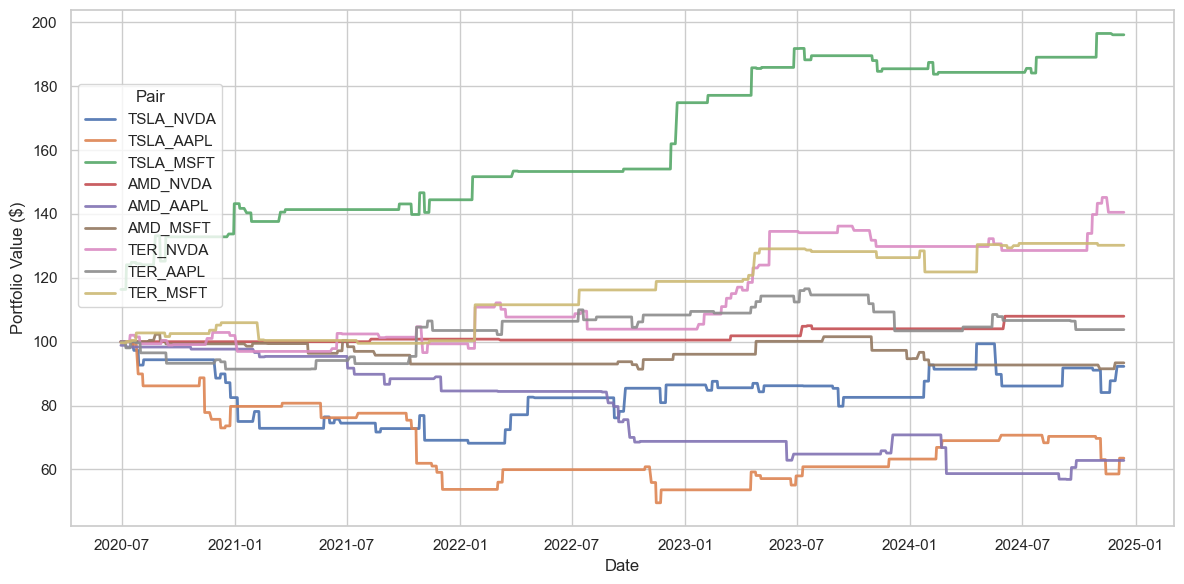

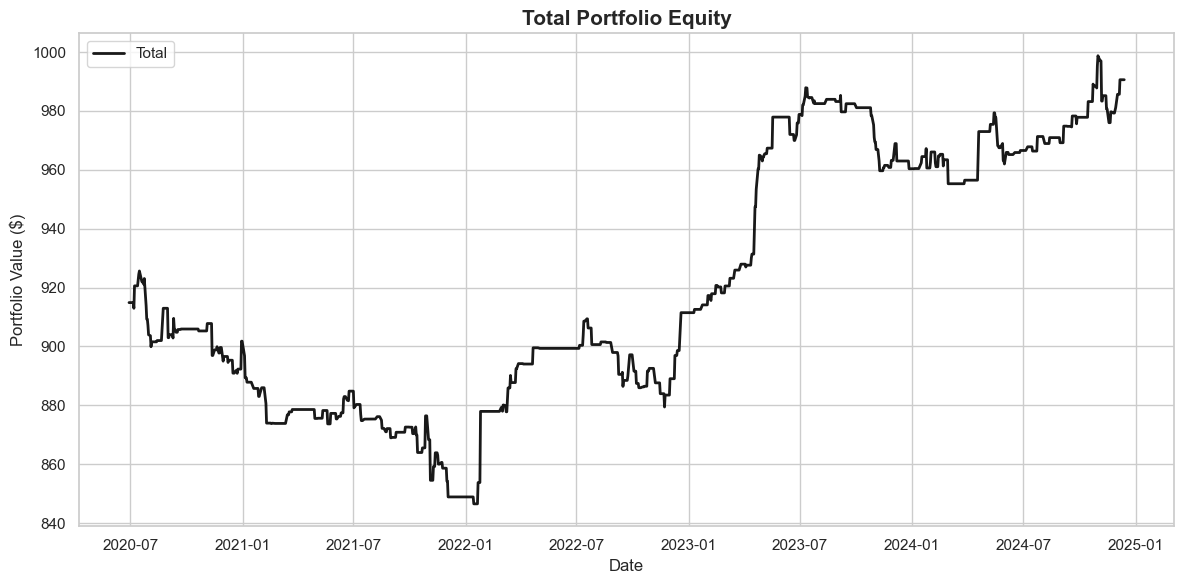

Summary
TSLA_NVDA: Final Value = $92.28, Total Return = -7.72%, Trades = 49
TSLA_AAPL: Final Value = $63.53, Total Return = -36.47%, Trades = 40
TSLA_MSFT: Final Value = $196.13, Total Return = 68.53%, Trades = 45
AMD_NVDA: Final Value = $107.98, Total Return = 7.98%, Trades = 7
AMD_AAPL: Final Value = $62.81, Total Return = -36.48%, Trades = 32
AMD_MSFT: Final Value = $93.38, Total Return = -6.62%, Trades = 29
TER_NVDA: Final Value = $140.53, Total Return = 40.53%, Trades = 50
TER_AAPL: Final Value = $103.79, Total Return = 3.79%, Trades = 44
TER_MSFT: Final Value = $130.20, Total Return = 30.66%, Trades = 32

Total Portfolio Performance
Initial Portfolio Value: $914.90
Final Portfolio Value:   $990.62
Total Return:            8.28%

Sharpe Ratios
TSLA_NVDA: Sharpe Ratio = -0.02
TSLA_AAPL: Sharpe Ratio = -0.45
TSLA_MSFT: Sharpe Ratio = 1.19
AMD_NVDA: Sharpe Ratio = 0.72
AMD_AAPL: Sharpe Ratio = -0.83
AMD_MSFT: Sharpe Ratio = -0.26
TER_NVDA: Sharpe Ratio = 0.74
TER_AAPL: Sharpe Ratio =

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)